# Visualization

> Complete visualization workflow: sidecar creation, aggregation, and map display

## Setup

Import the healpyxel package and core utilities:

In [ ]:
import healpyxel
from healpyxel import core
import pandas as pd
import numpy as np

print(f"healpyxel version: {healpyxel.__version__}")

healpyxel version: 0.1.0


## Test Data

Check available test data in the package:

In [ ]:
from pathlib import Path

# Look for test data
test_data_dir = Path('../test_data')
if test_data_dir.exists():
    print("Test data directory found!")
    print(f"\nContents:")
    for item in sorted(test_data_dir.iterdir()):
        if item.is_file():
            size_mb = item.stat().st_size / 1024 / 1024
            print(f"  {item.name}: {size_mb:.2f} MB")
        elif item.is_dir():
            n_files = len(list(item.glob('*')))
            print(f"  {item.name}/: {n_files} files")
else:
    print("Test data directory not found. Run create_test_data.sh to generate test data.")

Test data directory found!

Contents:
  README.md: 0.00 MB
  batches/: 10 files
  derived/: 1 files
  regions/: 0 files
  samples/: 3 files
  validation/: 2 files


## Quick Test with Sample Data

If test data is available, let's try a quick aggregation:

In [ ]:
# Check for sample data
sample_file = test_data_dir / 'samples/sample_50k.parquet'

if sample_file.exists():
    print(f"Loading sample: {sample_file.name}")
    df = pd.read_parquet(sample_file)
    
    print(f"\nShape: {df.shape}")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nFirst few rows:")
    display(df.head())
    
    # Check for lat/lon columns
    if 'latitude' in df.columns and 'longitude' in df.columns:
        print(f"\n✓ Found latitude/longitude columns for HEALPix conversion")
        print(f"  Lat range: [{df['latitude'].min():.2f}, {df['latitude'].max():.2f}]")
        print(f"  Lon range: [{df['longitude'].min():.2f}, {df['longitude'].max():.2f}]")
else:
    print("Sample data not found. Generate test data first:")
    print("  cd .. && bash create_test_data.sh")

Loading sample: sample_50k.parquet

Shape: (50000, 61)

Columns: ['ref_id', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q1', 'q2', 'q3', 'q4', 'obs_id', 'vis_slope', 'nir_slope', 'visnir_slope', 'norm_vis_slope', 'norm_nir_slope', 'norm_visnir_slope', 'curvature', 'norm_curvature', 'uv_downturn', 'color_index_310_390', 'color_index_415_750', 'color_index_750_415', 'color_index_750_950', 'r310', 'r390', 'r750', 'r950', 'r1050', 'r1400', 'r415', 'r433_2', 'r479_9', 'r556_9', 'r628_8', 'r748_7', 'r828_4', 'r898_8', 'r996_2', 'spot_number', 'lat_center', 'lon_center', 'surface', 'width', 'length', 'ang_incidence', 'ang_emission', 'ang_phase', 'azimuth', 'geometry']

First few rows:


,ref_id,a,b,c,d,e,f,g,h,i,...,lat_center,lon_center,surface,width,length,ang_incidence,ang_emission,ang_phase,azimuth,geometry
0,1310408274001158,0,1,1,1,9,1,1,0,0,...,5.186568,272.40450,1567133.40,1006.63727,1982.1799,43.049232,34.814793,77.85916,109.019295,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...
1,1335313413800913,0,0,0,0,9,1,1,0,0,...,-60.939438,71.77686,13564574.00,4064.49850,4249.2210,64.178116,37.690910,101.84035,111.930336,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...
2,1224306405800836,0,2,2,2,9,1,1,0,0,...,5.613894,54.23045,1755143.50,1013.51886,2204.9104,53.815990,24.053764,77.86254,99.559425,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...
3,1421301274400732,0,1,1,1,9,1,1,0,0,...,-41.672714,324.49740,23309360.00,6511.20950,4558.0470,52.841824,46.625698,99.40995,121.833626,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...
4,1310308273500668,0,0,0,0,9,1,1,0,0,...,26.975400,284.81708,905292.56,480.38028,2399.4622,56.780300,21.083624,77.85945,97.433360,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...


In [ ]:
import duckdb
from math import isnan
import pathlib
stats = []
# reuse/clear existing stats list
stats.clear()

# print("\nInspecting all parquet files in test data directory and collecting lat/lon stats:")
for parquet_file in test_data_dir.rglob('*.parquet'):
    size_mb = parquet_file.stat().st_size / 1024 / 1024
    rel = parquet_file.relative_to(test_data_dir)
    try:
        q = (
            f"SELECT COUNT(*) AS n_rows, "
            f"MIN(lat_center) AS lat_min, MAX(lat_center) AS lat_max, "
            f"MIN(lon_center) AS lon_min, MAX(lon_center) AS lon_max "
            f"FROM read_parquet('{parquet_file.as_posix()}')"
        )
        n_rows, lat_min, lat_max, lon_min, lon_max = duckdb.query(q).fetchone()
    except Exception:
        # If lat_center/lon_center missing or another error, still try to get row count
        try:
            n_rows = duckdb.query(f"SELECT COUNT(*) FROM read_parquet('{parquet_file.as_posix()}')").fetchone()[0]
        except Exception:
            n_rows = None
        lat_min = lat_max = lon_min = lon_max = None

    stats.append({
        "file": str(rel),
        "size_mb": size_mb,
        "n_rows": n_rows,
        "lat_min": lat_min,
        "lat_max": lat_max,
        "lon_min": lon_min,
        "lon_max": lon_max,
    })
    # print(f"  {rel}: {size_mb:.2f} MB, {n_rows} rows")

# Aggregate into a dataframe and display
df_stats = pd.DataFrame(stats)
df_stats['filename'] = df_stats['file'].apply(lambda x: pathlib.Path(x).stem)
display(df_stats)

,file,size_mb,n_rows,lat_min,lat_max,lon_min,lon_max,filename
0,samples/sample_50k.parquet,18.891136,50000,-74.986440,74.946884,0.020273,359.96555,sample_50k
1,samples/sample_5k.parquet,1.941895,5000,-74.954390,74.846540,0.274960,359.80890,sample_5k
2,samples/sample_25k.parquet,9.614980,25000,-74.934560,74.767715,0.057941,359.97324,sample_25k
3,derived/cli_quickstart/sample_50k.cell-healpix...,0.430335,54931,NaN,NaN,NaN,NaN,sample_50k.cell-healpix_assignment-fuzzy_nside...
4,derived/cli_quickstart/sample_50k-aggregated.c...,0.552613,12288,NaN,NaN,NaN,NaN,sample_50k-aggregated.cell-healpix_assignment-...
5,derived/cli_quickstart/sample_50k-aggregated.c...,1.302203,49152,NaN,NaN,NaN,NaN,sample_50k-aggregated.cell-healpix_assignment-...
6,derived/cli_quickstart/sample_50k.cell-healpix...,0.525922,59592,NaN,NaN,NaN,NaN,sample_50k.cell-healpix_assignment-fuzzy_nside...
7,validation/high_quality_subset.parquet,9.039313,25121,-74.992330,74.683150,175.000180,184.99979,high_quality_subset
8,validation/combined_batch_001_003.parquet,3.963343,10890,-74.627014,74.447170,175.000180,177.99991,combined_batch_001_003
9,batches/batch_009.parquet,1.613665,4417,-74.822310,74.647300,183.000080,183.99973,batch_009


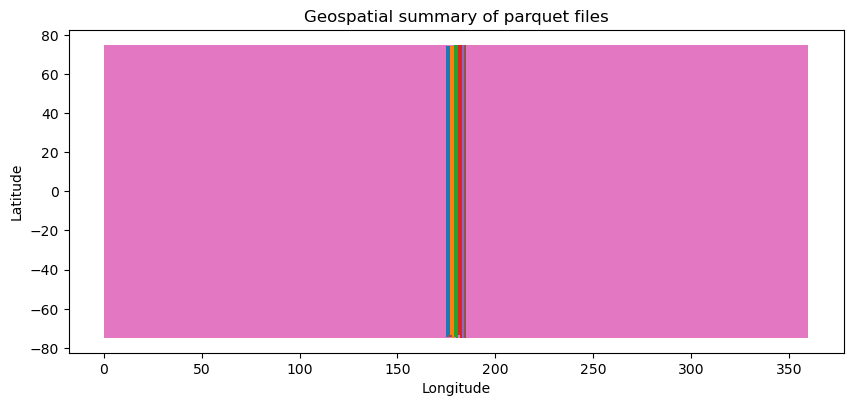

In [ ]:
# convert to geopandas creating a polygon box with lat_min	lat_max	lon_min	lon_max per file
import geopandas as gpd
from shapely.geometry import box
df_stats['geometry'] = df_stats.apply(
    lambda row: box(row['lon_min'], row['lat_min'], row['lon_max'], row['lat_max'])
    if not (isnan(row['lat_min']) or isnan(row['lat_max']) or isnan(row['lon_min']) or isnan(row['lon_max']))
    else None,
    axis=1
)
gdf_stats = gpd.GeoDataFrame(df_stats, geometry='geometry', crs='EPSG:4326')
ax = gdf_stats.plot(column='filename', legend=False, figsize=(10, 6))
ax.set_title("Geospatial summary of parquet files")
ax.set_xlabel("Longitude");
ax.set_ylabel("Latitude");

Text(0.5, 1.0, 'Geospatial coverage of parquet files (excluding sample files)')

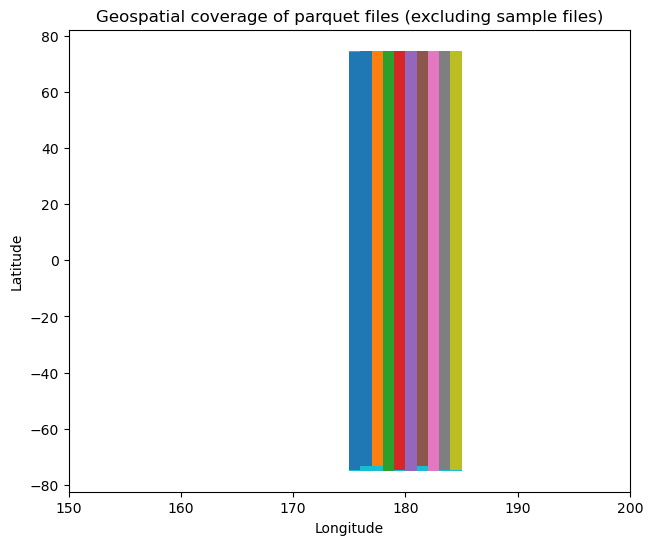

In [ ]:
# convert to geopandas creating a polygon box with lat_min	lat_max	lon_min	lon_max per file
ax = gdf_stats[~gdf_stats.filename.str.contains('sample')].plot(column='filename', legend=False, figsize=(20, 6), aspect=0.25)
ax.set_xlim([150, 200])
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geospatial coverage of parquet files (excluding sample files)')


## Create Sidecar for Sample Data

Now let's create a HEALPix sidecar for the sample data. We can do this in memory without writing to a file.

In [ ]:
# Load the 50k sample
import geopandas as gpd
from shapely import wkb

sample_file = test_data_dir / 'samples' / 'sample_50k.parquet'
print(f"Loading: {sample_file}")

# Read as regular pandas DataFrame first (geometry is stored as WKB binary)
df = pd.read_parquet(sample_file)
print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")

# Convert WKB geometry column to shapely geometries
if 'geometry' in df.columns:
    print("\nConverting WKB geometry to GeoDataFrame...")
    df['geometry'] = df['geometry'].apply(lambda x: wkb.loads(bytes(x)) if x is not None else None)
    gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')
    print(f"CRS: {gdf.crs}")
else:
    print("\nNo geometry column found!")
    gdf = df

# Show first few rows
gdf.head(3)

Loading: ../test_data/samples/sample_50k.parquet
Loaded 50000 rows
Columns: ['ref_id', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q1', 'q2', 'q3', 'q4', 'obs_id', 'vis_slope', 'nir_slope', 'visnir_slope', 'norm_vis_slope', 'norm_nir_slope', 'norm_visnir_slope', 'curvature', 'norm_curvature', 'uv_downturn', 'color_index_310_390', 'color_index_415_750', 'color_index_750_415', 'color_index_750_950', 'r310', 'r390', 'r750', 'r950', 'r1050', 'r1400', 'r415', 'r433_2', 'r479_9', 'r556_9', 'r628_8', 'r748_7', 'r828_4', 'r898_8', 'r996_2', 'spot_number', 'lat_center', 'lon_center', 'surface', 'width', 'length', 'ang_incidence', 'ang_emission', 'ang_phase', 'azimuth', 'geometry']

Converting WKB geometry to GeoDataFrame...
CRS: EPSG:4326


,ref_id,a,b,c,d,e,f,g,h,i,...,lat_center,lon_center,surface,width,length,ang_incidence,ang_emission,ang_phase,azimuth,geometry
0,1310408274001158,0,1,1,1,9,1,1,0,0,...,5.186568,272.40450,1567133.4,1006.63727,1982.1799,43.049232,34.814793,77.85916,109.019295,"POLYGON ((272.39758 5.16433, 272.41583 5.18307..."
1,1335313413800913,0,0,0,0,9,1,1,0,0,...,-60.939438,71.77686,13564574.0,4064.49850,4249.2210,64.178116,37.690910,101.84035,111.930336,"POLYGON ((71.72596 -60.89612, 71.69186 -60.963..."
2,1224306405800836,0,2,2,2,9,1,1,0,0,...,5.613894,54.23045,1755143.5,1013.51886,2204.9104,53.815990,24.053764,77.86254,99.559425,"POLYGON ((54.24406 5.63592, 54.22025 5.62014, ..."


In [ ]:
# Create sidecar in memory using the process_partition function
from healpyxel.sidecar import process_partition

# Parameters
nside = 32  # HEALPix resolution
mode = 'fuzzy'  # 'fuzzy' allows multiple cells per geometry, 'strict' only single-cell geometries

# Process the GeoDataFrame
sidecar_df = process_partition(
    gdf=gdf,
    nside=nside,
    mode=mode,
    base_index=0,  # Start source_id from 0
    lon_convention='0_360',  # Use '0_360' or '-180_180' (underscores, not hyphens!)
)

print(f"Created sidecar with {len(sidecar_df)} assignments")
print(f"Unique geometries: {sidecar_df['source_id'].nunique()}")
print(f"Unique HEALPix cells: {sidecar_df['healpix_id'].nunique()}")
print(f"\nSidecar columns: {list(sidecar_df.columns)}")
print(f"Sidecar dtypes:\n{sidecar_df.dtypes}")

# Show first few assignments
sidecar_df.head(10)

2026-02-03 13:18:50,894 INFO Partition (lon_convention=0_360): processed 50000 geometries, dropped 12 (0.0%) total [pre-filter: 12, post-processing: 0]


Created sidecar with 54931 assignments
Unique geometries: 49988
Unique HEALPix cells: 10860

Sidecar columns: ['source_id', 'healpix_id', 'weight']
Sidecar dtypes:
source_id       int64
healpix_id     UInt64
weight        float64
dtype: object


,source_id,healpix_id,weight
0,0,7943,1.0
1,1,8287,1.0
2,2,5819,1.0
3,3,11685,1.0
4,4,3618,1.0
5,5,3805,1.0
6,6,9522,1.0
7,7,10975,1.0
8,8,1820,1.0
9,9,3710,1.0


In [ ]:
# Check how many cells each geometry touches (for fuzzy mode)
assignments_per_geom = sidecar_df.groupby('source_id').size()

print(f"Assignment statistics:")
print(f"  Min cells per geometry: {assignments_per_geom.min()}")
print(f"  Max cells per geometry: {assignments_per_geom.max()}")
print(f"  Mean cells per geometry: {assignments_per_geom.mean():.2f}")
print(f"  Median cells per geometry: {assignments_per_geom.median():.0f}")

# Show distribution
print(f"\nDistribution of assignments per geometry:")
print(assignments_per_geom.value_counts().sort_index().head(10))

Assignment statistics:
  Min cells per geometry: 1
  Max cells per geometry: 4
  Mean cells per geometry: 1.10
  Median cells per geometry: 1

Distribution of assignments per geometry:
1    45331
2     4396
3      236
4       25
Name: count, dtype: int64


In [ ]:
# Optional: Save sidecar to file for later use
sidecar_output = pathlib.Path(f'/tmp/sample_50k_sidecar_nside{nside}_{mode}.parquet')
sidecar_df.to_parquet(sidecar_output, index=False)
print(f"Saved sidecar to: {sidecar_output}")
print(f"File size: {sidecar_output.stat().st_size / 1024:.2f} KB")

Saved sidecar to: /tmp/sample_50k_sidecar_nside32_fuzzy.parquet
File size: 441.63 KB


## Aggregate Data by HEALPix Cells

Now let's use the sidecar to aggregate the `r1050` column from the original data by HEALPix cells.

In [ ]:
# Import the aggregate module
from healpyxel.aggregate import aggregate_by_sidecar

# Check if r1050 column exists
if 'r1050' in gdf.columns:
    print("✓ Column 'r1050' found in the data")
    print(f"  Range: [{gdf['r1050'].min():.3f}, {gdf['r1050'].max():.3f}]")
    print(f"  Missing values: {gdf['r1050'].isna().sum()} / {len(gdf)}")
else:
    print("❌ Column 'r1050' not found!")
    print(f"Available columns: {list(gdf.columns)}")

✓ Column 'r1050' found in the data
  Range: [-0.050, 0.325]
  Missing values: 0 / 50000


In [ ]:
# Aggregate r1050 by HEALPix cells with explicit aggregation functions
# Convert GeoDataFrame to regular DataFrame for aggregation (geometry not needed)
df_for_agg = pd.DataFrame(gdf.drop(columns='geometry'))

# Perform aggregation with all available functions explicitly
aggregated = aggregate_by_sidecar(
    original=df_for_agg,
    sidecar=sidecar_df,
    value_columns=['r1050'],
    aggs=['mean', 'median', 'std', 'mad', 'robust_std'],  # Explicit list of aggregations
    source_id_col='source_id',
    healpix_col='healpix_id',
    min_count=1,  # Minimum number of sources per cell
   sentinel_threshold=1e30  # Mask extreme values
)

print(f"Aggregated data shape: {aggregated.shape}")
print(f"Number of HEALPix cells with data: {len(aggregated)}")
print(f"\nAggregated columns: {list(aggregated.columns)}")

# Show first few rows
aggregated.head(10)

2026-02-03 13:18:51,041 INFO Creating source_id column from DataFrame index
2026-02-03 13:18:51,074 INFO Sidecar source_id overlap: 49988/49988 (100.0%)
2026-02-03 13:18:51,075 INFO Merging sidecar with original data
2026-02-03 13:18:51,080 INFO Grouping by healpix_id and computing aggregations
2026-02-03 13:18:51,159 INFO Processing 10860 HEALPix cells


Aggregating HEALPix cells:   0%|          | 0/10860 [00:00<?, ?cell/s]

2026-02-03 13:18:54,635 INFO Aggregation complete: 10860 cells with data


Aggregated data shape: (10860, 6)
Number of HEALPix cells with data: 10860

Aggregated columns: ['r1050_mean', 'r1050_median', 'r1050_std', 'r1050_mad', 'r1050_robust_std', 'n_sources']


,r1050_mean,r1050_median,r1050_std,r1050_mad,r1050_robust_std,n_sources
healpix_id,,,,,,
0,0.048616,0.047857,0.003759,0.002672,0.003962,4
1,0.051467,0.052283,0.002976,0.001888,0.002799,6
2,0.049697,0.049118,0.003637,0.002289,0.003394,6
3,0.059066,0.063241,0.007149,0.001711,0.002537,3
4,0.051262,0.051523,0.006552,0.002510,0.003721,9
5,0.047092,0.047639,0.008176,0.003183,0.004719,7
6,0.058219,0.058195,0.002682,0.002040,0.003024,6
7,0.053656,0.054208,0.008577,0.006288,0.009323,8
8,0.037711,0.037711,0.008823,0.008823,0.013080,2


### Interpret the Results

Each row represents one HEALPix cell with:
- `healpix_id`: The HEALPix cell identifier
- `r1050_mean`: Mean of r1050 values in this cell
- `r1050_median`: Median value (less affected by outliers)
- `r1050_std`: Standard deviation (spread of values)
- `r1050_mad`: Median Absolute Deviation (robust measure of spread)
- `r1050_robust_std`: MAD * 1.4826 (approximates standard deviation for normal distributions)
- `n_sources`: Number of source measurements in this cell, for all columns

Let's examine the statistics of the aggregated data:

In [ ]:
# Display summary statistics of the aggregated results
print("Summary statistics for aggregated HEALPix cells:\n")
print(aggregated.describe())

# Check distribution of source counts per cell
print("\n\nDistribution of source counts per HEALPix cell:")
print(aggregated['n_sources'].describe())
print(f"\nCells with only 1 source: {(aggregated['n_sources'] == 1).sum()}")
print(f"Cells with 2-5 sources: {((aggregated['n_sources'] >= 2) & (aggregated['n_sources'] <= 5)).sum()}")
print(f"Cells with 5+ sources: {(aggregated['n_sources'] > 5).sum()}")

Summary statistics for aggregated HEALPix cells:

         r1050_mean  r1050_median     r1050_std     r1050_mad  \
count  10860.000000  10860.000000  10860.000000  10860.000000   
mean       0.054837      0.054731      0.004838      0.003076   
std        0.008117      0.008069      0.004290      0.002981   
min        0.008949      0.008949      0.000000      0.000000   
25%        0.049472      0.049385      0.001861      0.000960   
50%        0.053936      0.053849      0.004238      0.002508   
75%        0.059213      0.059099      0.006812      0.004329   
max        0.141338      0.141338      0.133480      0.032018   

       r1050_robust_std     n_sources  
count      10860.000000  10860.000000  
mean           0.004561      5.058103  
std            0.004420      4.835600  
min            0.000000      1.000000  
25%            0.001424      2.000000  
50%            0.003718      4.000000  
75%            0.006418      6.000000  
max            0.047470     98.000000  


Di

### HEALPix Metadata

The aggregation results don't automatically include HEALPix metadata. You need to track this separately or read it from a saved sidecar file. For in-memory workflows, store metadata explicitly:

In [ ]:
# Store HEALPix metadata with aggregated results
metadata = {
    'healpix_nside': nside,
    'healpix_order': 'nested',  # HEALPix default in healpyxel
    'healpix_mode': mode,
}

# Access metadata like in your older scripts
nside_value = int(metadata['healpix_nside'])
order = metadata['healpix_order']
nest_flag = (order == 'nested')

print(f"HEALPix Configuration:")
print(f"  nside: {nside_value}")
print(f"  order: {order}")
print(f"  nested: {nest_flag}")
print(f"  mode: {metadata['healpix_mode']}")

HEALPix Configuration:
  nside: 32
  order: nested
  nested: True
  mode: fuzzy


**Reading metadata from saved sidecar files:**

If you save the sidecar to a parquet file (like we did earlier), the metadata is embedded in the parquet schema and can be read back:

In [ ]:
# Read metadata from saved sidecar file
import pyarrow.parquet as pq

sidecar_file = pathlib.Path(f'/tmp/sample_50k_sidecar_nside{nside}_{mode}.parquet')
if sidecar_file.exists():
    # Read parquet metadata
    parquet_file = pq.ParquetFile(sidecar_file)
    schema_metadata = parquet_file.schema_arrow.metadata
    
    # Decode metadata (stored as bytes)
    file_metadata = {k.decode(): v.decode() for k, v in schema_metadata.items()} if schema_metadata else {}
    
    print("Metadata from saved sidecar file:")
    print(f"  nside: {file_metadata.get('nside', 'N/A')}")
    print(f"  mode: {file_metadata.get('mode', 'N/A')}")
    print(f"  order: {file_metadata.get('order', 'N/A')}")
    
    # Use it like your older scripts
    if 'nside' in file_metadata:
        nside_from_file = int(file_metadata['nside'])
        order_from_file = file_metadata['order']
        nest_flag_from_file = (order_from_file == 'nested')
        print(f"\n  → nest_flag: {nest_flag_from_file}")
else:
    print(f"Sidecar file not found: {sidecar_file}")

Metadata from saved sidecar file:
  nside: N/A
  mode: N/A
  order: N/A


## Visualize HEALPix Map

Before visualizing, we need to densify the sparse aggregated data to include all HEALPix cells (including empty ones).

We'll use the visualization utilities from `healpyxel.visualization` module.

In [ ]:
# Densify the aggregated data to include all HEALPix cells
from healpyxel.aggregate import densify_healpix_aggregates

# The aggregated DataFrame only contains cells with data (sparse)
# Densify to create a full HEALPix grid with all npix = 12 * nside^2 cells
aggregated_dense = densify_healpix_aggregates(
    agg_sparse_df=aggregated,
    nside=nside,
    healpix_col='healpix_id'
)

print(f"Sparse aggregated cells: {len(aggregated)}")
print(f"Dense HEALPix grid cells: {len(aggregated_dense)} (expected: {12 * nside**2})")
print(f"\nEmpty cells (no data): {aggregated_dense['r1050_median'].isna().sum()}")
print(f"Cells with data: {aggregated_dense['r1050_median'].notna().sum()}")

# Show first few rows including empty cells
aggregated_dense.head(10)

2026-02-03 13:18:55,069 INFO Densified from 10860 to 12288 cells (nside=32)


Sparse aggregated cells: 10860
Dense HEALPix grid cells: 12288 (expected: 12288)

Empty cells (no data): 1428
Cells with data: 10860


,r1050_mean,r1050_median,r1050_std,r1050_mad,r1050_robust_std,n_sources
healpix_id,,,,,,
0,0.048616,0.047857,0.003759,0.002672,0.003962,4.0
1,0.051467,0.052283,0.002976,0.001888,0.002799,6.0
2,0.049697,0.049118,0.003637,0.002289,0.003394,6.0
3,0.059066,0.063241,0.007149,0.001711,0.002537,3.0
4,0.051262,0.051523,0.006552,0.002510,0.003721,9.0
5,0.047092,0.047639,0.008176,0.003183,0.004719,7.0
6,0.058219,0.058195,0.002682,0.002040,0.003024,6.0
7,0.053656,0.054208,0.008577,0.006288,0.009323,8.0
8,0.037711,0.037711,0.008823,0.008823,0.013080,2.0


In [ ]:
# Import visualization utilities from healpyxel
from healpyxel.visualization import prepare_healpix_map
import numpy as np

# Prepare the HEALPix map for visualization
output_column = 'r1050_median'

healpix_map, valid_pixels, invalid_pixels, mappable = prepare_healpix_map(
    aggregated_dense,
    output_column=output_column,
    equalize=True,  # Apply histogram equalization for better contrast
    percentile_cutoff=None,  # Optional: clip outliers, e.g., 5 for [5%, 95%]
    cmap='Spectral_r'
)

print(f"HEALPix map prepared:")
print(f"  Total pixels: {len(healpix_map)}")
print(f"  Valid pixels: {valid_pixels.sum()}")
print(f"  Invalid pixels: {invalid_pixels.sum()}")


HEALPix map prepared:
  Total pixels: 12288
  Valid pixels: 10860
  Invalid pixels: 1428


2026-02-03 13:18:56,234 INFO 0.0 180.0 -180.0 180.0
2026-02-03 13:18:56,235 INFO The interval between parallels is 30 deg -0.00'.
2026-02-03 13:18:56,236 INFO The interval between meridians is 30 deg -0.00'.


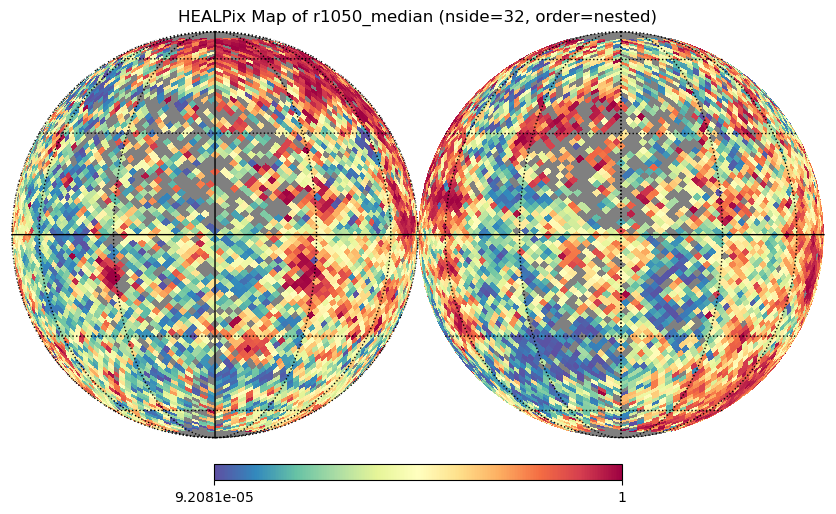

In [ ]:
#| eval: false
import healpy

ax = healpy.visufunc.orthview(healpix_map, nest=nest_flag,
                         title=f'HEALPix Map of {output_column} (nside={nside}, order={order})',
                         cmap='Spectral_r',flip='geo', norm='None', xsize=2500)
healpy.visufunc.graticule()


In [ ]:
import skyproj
from matplotlib import pyplot as plt

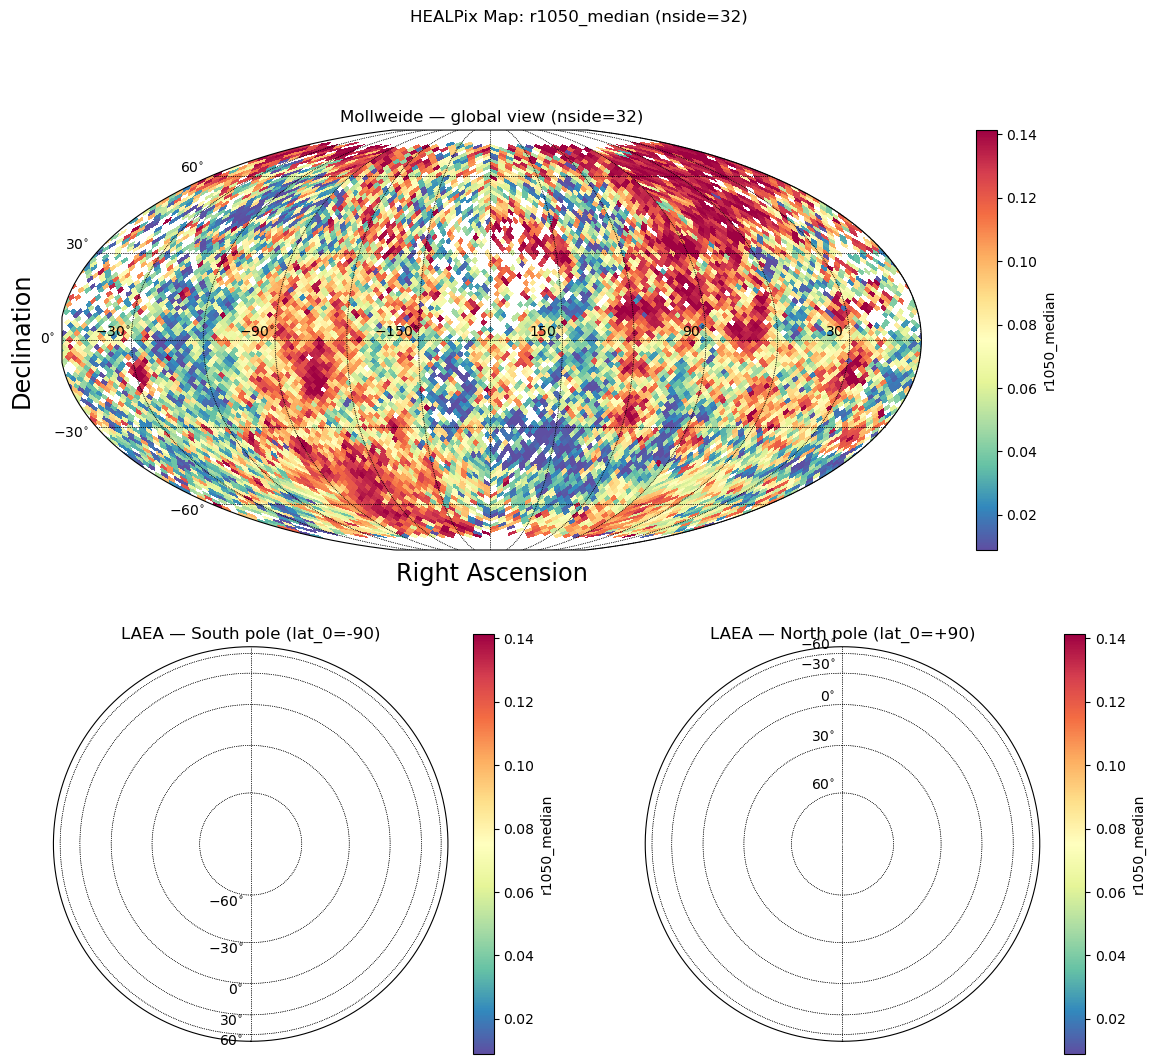

In [ ]:
#| eval: false
healpix_map[invalid_pixels] = healpy.UNSEEN
# healpix_map_masked = np.ma.masked_where(invalid_pixels, healpix_map)

fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# Top row: full-width Mollweide projection
ax_top = fig.add_subplot(gs[0, :])
sp_moll = skyproj.MollweideSkyproj(ax=ax_top, lon_0=-180, longitude_ticks='symmetric')
_ = sp_moll.draw_hpxmap(
    healpix_map,
    nest=nest_flag,
    cmap='Spectral_r',
    zoom=True,
)
fig.colorbar(mappable, ax=sp_moll.ax, orientation='vertical', label=output_column)
sp_moll.ax.set_title(f'Mollweide — global view (nside={nside})')

# Bottom-left: LAEA centered on South pole
ax_bl = fig.add_subplot(gs[1, 0])
sp_south = skyproj.LaeaSkyproj(ax=ax_bl, lat_0=-90.0)
_ = sp_south.draw_hpxmap(
    healpix_map,
    nest=nest_flag,
    cmap='Spectral_r',
    zoom=False,
)
fig.colorbar(mappable, ax=sp_south.ax, orientation='vertical', label=output_column)
sp_south.ax.set_title('LAEA — South pole (lat_0=-90)')

# Bottom-right: LAEA centered on North pole
ax_br = fig.add_subplot(gs[1, 1])
sp_north = skyproj.LaeaSkyproj(ax=ax_br, lat_0=90.0)
_ = sp_north.draw_hpxmap(
    healpix_map,
    nest=nest_flag,
    cmap='Spectral_r',
    zoom=False,
)
fig.colorbar(mappable, ax=sp_north.ax, orientation='vertical', label=output_column)
sp_north.ax.set_title('LAEA — North pole (lat_0=+90)')

plt.suptitle(f'HEALPix Map: {output_column} (nside={nside})');
# plt.tight_layout()


## Generate data in CLI and Visualize

The same data generated here can be produced with the script in `examples/cli_regrid_sample_50k.sh` :

```bash
#!/usr/bin/env bash
set -euo pipefail

# define variables
ROOT_DIR="$(cd "$(dirname "${BASH_SOURCE[0]}")/.." && pwd)"
INPUT="$ROOT_DIR/test_data/samples/sample_50k.parquet"
OUT_DIR="$ROOT_DIR/test_data/derived/cli_quickstart"
NSIDE=32
MODE=fuzzy
LON_CONVENTION=0_360
# generate output directly
mkdir -p "$OUT_DIR"

# 2) Aggregate sparse regridded map
healpix_aggregate \
  --input "$INPUT" \
  --sidecar-dir "$OUT_DIR" \
  --sidecar-index 0 \
  --aggregate \
  --columns r1050 \
  --aggs mean median std mad robust_std \
  --min-count 1 \
  --output "$OUT_DIR/sample_50k_nside${NSIDE}_r1050_sparse_aggregate.parquet"
# 3) Aggregate (densified) regridded map
healpix_aggregate \
  --input "$INPUT" \
  --sidecar-dir "$OUT_DIR" \
  --sidecar-index 0 \
  --aggregate \
  --columns r1050 \
  --aggs mean median std mad robust_std \
  --min-count 1 \
  --densify \
  --output "$OUT_DIR/sample_50k_nside${NSIDE}_r1050_dense_aggregate.parquet"

```

In [ ]:
import json
import rich
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Define paths to CLI outputs
cli_output_dir = Path('../test_data/derived/cli_quickstart')

### Load CLI-Generated Products

Load the sidecar and aggregated maps created by the CLI script above.

In [ ]:
# Load sidecar metadata
sidecar_meta_path = cli_output_dir / 'sample_50k.cell-healpix_assignment-fuzzy_nside-32_order-nested.meta.json'
if sidecar_meta_path.exists():
    with open(sidecar_meta_path, 'r') as f:
        sidecar_metadata = json.load(f)
    
    print("Sidecar Metadata:")
    print("="*60)
    print(sidecar_metadata)
else:
    print(f"Sidecar metadata not found: {sidecar_meta_path}")
    print("Run the CLI script first: bash examples/cli_regrid_sample_50k.sh")

Sidecar Metadata:
{'processing': {'stage': 'sidecar', 'timestamp': '2026-02-03T12:06:33.952423Z', 'source_file': '/home/kidpixo/Documents/work/MESSENGER/MASCS_gn_dlr_processed/healpyxel/test_data/samples/sample_50k.parquet', 'output_file': '/home/kidpixo/Documents/work/MESSENGER/MASCS_gn_dlr_processed/healpyxel/test_data/derived/cli_quickstart/sample_50k.cell-healpix_assignment-fuzzy_nside-32_order-nested.parquet'}, 'healpix': {'nside': 32, 'mode': 'fuzzy', 'order': 'nested', 'npix': 12288}, 'coordinates': {'lon_convention': '0_360', 'lon_range': [0, 360], 'lat_range': [-90, 90]}, 'processing_params': {'ncores': 15, 'coalesced': True, 'data_psf': 'none', 'data_psf_sigma_level': 2.0, 'cell_psf': 'none', 'cell_psf_sigma_level': 2.0, 'psf_combine': 'multiply', 'psf_normalize': True}}


In [ ]:
# Load sidecar parquet file using metadata
if sidecar_meta_path.exists():
    # Extract output file path from metadata
    sidecar_path = Path(sidecar_metadata['processing']['output_file'])
    
    if sidecar_path.exists():
        sidecar_cli = pd.read_parquet(sidecar_path)
        
        print(f"Sidecar DataFrame:")
        print(f"  Shape: {sidecar_cli.shape}")
        print(f"  Columns: {list(sidecar_cli.columns)}")
        print(f"  Dtypes:\n{sidecar_cli.dtypes}")
        print(f"\n  Unique sources: {sidecar_cli['source_id'].nunique()}")
        print(f"  Unique HEALPix cells: {sidecar_cli['healpix_id'].nunique()}")
        print(f"  Total assignments: {len(sidecar_cli)}")
        
        # Check for weight column
        if 'weight' in sidecar_cli.columns:
            print(f"\n  Has 'weight' column: Yes")
            print(f"    Weight range: [{sidecar_cli['weight'].min():.6f}, {sidecar_cli['weight'].max():.6f}]")
        else:
            print(f"\n  Has 'weight' column: No")
        
        print(f"\n  First few rows:")
        display(sidecar_cli.head(10))
    else:
        print(f"Sidecar file not found: {sidecar_path}")
else:
    print(f"Sidecar metadata not found: {sidecar_meta_path}")
    print("Run the CLI script first: bash examples/cli_regrid_sample_50k.sh")

Sidecar DataFrame:
  Shape: (54931, 3)
  Columns: ['source_id', 'healpix_id', 'weight']
  Dtypes:
source_id       int64
healpix_id     uint64
weight        float64
dtype: object

  Unique sources: 49988
  Unique HEALPix cells: 10860
  Total assignments: 54931

  Has 'weight' column: Yes
    Weight range: [1.000000, 1.000000]

  First few rows:


,source_id,healpix_id,weight
0,0,7943,1.0
1,1,8287,1.0
2,2,5819,1.0
3,3,11685,1.0
4,4,3618,1.0
5,5,3805,1.0
6,6,9522,1.0
7,7,10975,1.0
8,8,1820,1.0
9,9,3710,1.0


### Load Sparse Aggregated Map

The sparse map contains only cells with data. We'll load it and densify it for visualization.

In [ ]:
# Load sparse aggregate using metadata
from healpyxel.metadata import HEALPyxelxMetadata

sparse_agg_meta_path = cli_output_dir / 'sample_50k_nside32_r1050_sparse_aggregate.meta.json'
if sparse_agg_meta_path.exists():
    # Read and validate metadata
    with open(sparse_agg_meta_path, 'r') as f:
        sparse_meta = json.load(f)
    
    # Validate metadata structure
    sparse_metadata = HEALPyxelxMetadata.from_dict(sparse_meta)
    print(f"Sparse Aggregate Metadata validated:")
    print(f"  File type: {sparse_metadata.file_type}")
    print(f"  HEALPix nside: {sparse_metadata.nside}")
    print(f"  HEALPix order: {sparse_metadata.order}")
    
    # Extract output file path from metadata
    sparse_agg_path = Path(sparse_meta['processing']['output_file'])
    
    if sparse_agg_path.exists():
        sparse_agg = pd.read_parquet(sparse_agg_path)
        # Verify index
        assert sparse_agg.index.name == 'healpix_id', f"Expected index 'healpix_id', got {sparse_agg.index.name}"

        ######## WARNING ######## 
        # When you call .set_index('healpix_id') on a DataFrame where healpix_id is already the index, 
        # pandas creates a new integer index and moves the old index to a column, causing chaos.
        # sparse_agg = pd.read_parquet(sparse_agg_path).set_index('healpix_id')
        #########################

        print(f"\nSparse Aggregated Map:")
        print(f"  Shape: {sparse_agg.shape}")
        print(f"  Columns: {list(sparse_agg.columns)}")
        print(f"  Index name: {sparse_agg.index.name}")
        print(f"\n  Statistics:")
        print(f"    Cells with data: {len(sparse_agg)}")
        print(f"    Expected cells (12*nside²): {12 * 32**2} = 12,288")
        print(f"    Coverage: {len(sparse_agg) / (12 * 32**2) * 100:.2f}%")
        
        print(f"\n  First few rows:")
        display(sparse_agg.head(10))

        # Densify the sparse map with proper alignment
        from healpyxel.aggregate import densify_healpix_aggregates

        sparse_agg_dense = densify_healpix_aggregates(
            agg_sparse_df=sparse_agg,
            nside=32,
            healpix_col='healpix_id'
        )
        
        # CRITICAL: Sort by healpix_id and reset index to align with pixel positions
        sparse_agg_dense = sparse_agg_dense.sort_index()

        # Verify alignment
        assert len(sparse_agg_dense) == 12 * 32**2, f"Expected {12*32**2}, got {len(sparse_agg_dense)}"
        assert sparse_agg_dense.index.equals(pd.RangeIndex(0, 12 * 32**2)), "Index not 0..12287"

        print(f"✓ Sparse densified aligned: {len(sparse_agg_dense)} rows, index 0..{len(sparse_agg_dense)-1}")
        print(f"  After densification:")
        print(f"    Total cells: {len(sparse_agg_dense)}")
        print(f"    Empty cells: {sparse_agg_dense['r1050_median'].isna().sum()}")
        print(f"    Cells with data: {sparse_agg_dense['r1050_median'].notna().sum()}")
    else:
        print(f"Sparse aggregate file not found: {sparse_agg_path}")
else:
    print(f"Sparse aggregate metadata not found: {sparse_agg_meta_path}")
    print("Run the CLI script first: bash examples/cli_regrid_sample_50k.sh")

Sparse aggregate metadata not found: ../test_data/derived/cli_quickstart/sample_50k_nside32_r1050_sparse_aggregate.meta.json
Run the CLI script first: bash examples/cli_regrid_sample_50k.sh


### Load Dense Aggregated Map

The dense map already includes all HEALPix cells (with NaN for empty cells).

In [ ]:
# Load dense aggregate using metadata
from healpyxel.metadata import HEALPyxelxMetadata

dense_agg_meta_path = cli_output_dir / 'sample_50k_nside32_r1050_dense_aggregate.meta.json'
if dense_agg_meta_path.exists():
    # Read and validate metadata
    with open(dense_agg_meta_path, 'r') as f:
        dense_meta = json.load(f)
    
    # Validate metadata structure
    dense_metadata = HEALPyxelxMetadata.from_dict(dense_meta)
    print(f"Dense Aggregate Metadata validated:")
    print(f"  File type: {dense_metadata.file_type}")
    print(f"  HEALPix nside: {dense_metadata.nside}")
    print(f"  HEALPix order: {dense_metadata.order}")
    
    # Extract output file path from metadata
    dense_agg_path = Path(dense_meta['processing']['output_file'])
    
    if dense_agg_path.exists():
        dense_agg = pd.read_parquet(dense_agg_path)
        
        print(f"\nDense Aggregated Map:")
        print(f"  Shape: {dense_agg.shape}")
        print(f"  Columns: {list(dense_agg.columns)}")
        print(f"  Index name: {dense_agg.index.name}")
        print(f"\n  Statistics:")
        print(f"    Total cells: {len(dense_agg)}")
        print(f"    Expected cells (12*nside²): {12 * 32**2} = 12,288")
        print(f"    Empty cells: {dense_agg['r1050_median'].isna().sum()}")
        print(f"    Cells with data: {dense_agg['r1050_median'].notna().sum()}")
        
        print(f"\n  First 10 rows (including empty cells):")
        display(dense_agg.head(10))
        
        # Ensure dense_agg is also sorted and reindexed (should already be, but verify)
        if dense_agg.index.name == 'healpix_id':
            dense_agg = dense_agg.sort_index()
        
        assert len(dense_agg) == 12 * 32**2 and dense_agg.index.equals(pd.RangeIndex(0, 12*32**2)), \
            "dense_agg alignment failed"

        print(f"✓ Dense agg aligned: {len(dense_agg)} rows")

        # Verify densification: compare with sparse densified version
        if 'sparse_agg_dense' in locals():
            # Compare non-NaN values
            sparse_valid = sparse_agg_dense['r1050_median'].notna()
            dense_valid = dense_agg['r1050_median'].notna()
            
            print(f"\n  Validation:")
            print(f"    Densified sparse matches dense: {(sparse_valid == dense_valid).all()}")
            if (sparse_valid == dense_valid).all():
                # Check if values are identical
                matching_cells = sparse_agg_dense.loc[sparse_valid, 'r1050_median'].values == dense_agg.loc[dense_valid, 'r1050_median'].values
                print(f"    Values match: {matching_cells.all()}")
    else:
        print(f"Dense aggregate file not found: {dense_agg_path}")
else:
    print(f"Dense aggregate metadata not found: {dense_agg_meta_path}")
    print("Run the CLI script first: bash examples/cli_regrid_sample_50k.sh")

Dense aggregate metadata not found: ../test_data/derived/cli_quickstart/sample_50k_nside32_r1050_dense_aggregate.meta.json
Run the CLI script first: bash examples/cli_regrid_sample_50k.sh


### Visualize CLI-Generated Maps

Create HEALPix visualizations using the dense aggregated map from CLI.

In [ ]:
#| eval: false
if 'dense_agg' in locals() and 'sparse_agg_dense' in locals():
    # Prepare HEALPix maps for visualization (both dense and sparse-densified)
    from healpyxel.visualization import prepare_healpix_map
    import healpy
    import skyproj
    
    output_col = 'r1050_median'
    nside_cli = 32
    
    # Prepare dense map
    healpix_map_dense, valid_pix_dense, invalid_pix_dense, mappable_dense = prepare_healpix_map(
        dense_agg.reset_index(),
        output_column=output_col,
        equalize=True,
        percentile_cutoff=None,
        cmap='Spectral_r'
    )
    healpix_map_dense[invalid_pix_dense] = healpy.UNSEEN
    
    # Prepare sparse-densified map
    healpix_map_sparse, valid_pix_sparse, invalid_pix_sparse, mappable_sparse = prepare_healpix_map(
        sparse_agg_dense,
        output_column=output_col,
        equalize=True,
        percentile_cutoff=None,
        cmap='Spectral_r'
    )
    healpix_map_sparse[invalid_pix_sparse] = healpy.UNSEEN
    
    print(f"Prepared HEALPix maps for comparison:")
    print(f"  Dense map - Valid pixels: {valid_pix_dense.sum()}")
    print(f"  Sparse (densified) map - Valid pixels: {valid_pix_sparse.sum()}")
    print(f"  Maps are identical: {np.allclose(healpix_map_dense[valid_pix_dense], healpix_map_sparse[valid_pix_sparse], equal_nan=True)}")
    
    # Create visualization with 2 rows
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Top: Dense aggregate (CLI --densify)
    sp_dense = skyproj.MollweideSkyproj(ax=axes[0], lon_0=-180, longitude_ticks='symmetric')
    _ = sp_dense.draw_hpxmap(
        healpix_map_dense,
        nest=True,
        cmap='Spectral_r',
        zoom=True,
    )
    fig.colorbar(mappable_dense, ax=sp_dense.ax, orientation='vertical', label=output_col, fraction=0.046, pad=0.04)
    sp_dense.ax.set_title(f'Dense Aggregate (CLI --densify) — nside={nside_cli}')
    
    # Bottom: Sparse aggregate (manually densified)
    sp_sparse = skyproj.MollweideSkyproj(ax=axes[1], lon_0=-180, longitude_ticks='symmetric')
    _ = sp_sparse.draw_hpxmap(
        healpix_map_sparse,
        nest=True,
        cmap='Spectral_r',
        zoom=True,
    )
    fig.colorbar(mappable_sparse, ax=sp_sparse.ax, orientation='vertical', label=output_col, fraction=0.046, pad=0.04)
    sp_sparse.ax.set_title(f'Sparse Aggregate (manually densified) — nside={nside_cli}')
    
    plt.suptitle(f'CLI-Generated HEALPix Maps Comparison: {output_col}', y=0.98)
    plt.tight_layout()
else:
    print("Dense and/or sparse aggregate not loaded. Run CLI script first.")

Dense and/or sparse aggregate not loaded. Run CLI script first.
